In [1]:
import json
import torch
import numpy as np
import random
import os
import pandas as pd
import sys
import random
import math
import argparse
import yaml
from pathlib import Path
import datetime
import wandb
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt


In [2]:
def make_unitary(v):
    """
    Makes input unitary (Fourier components have magnitude of 1)
    """
    fv = torch.fft.fft(v.double(), axis=1)
    fv = fv/torch.sqrt(fv.real**2 + fv.imag**2)
    return torch.fft.ifft(fv, axis=1).real.type_as(v)

def make_tensor_unitary(v):
    """
    Makes input tensor unitary (Fourier components have magnitude of 1)
    """
    fv = torch.fft.fft(v, axis=1)
    fv = fv/torch.sqrt(fv.real**2 + fv.imag**2)
    return torch.fft.ifft(fv, axis=1).real

def invert(a, dim):
    """
    Inverts input under binding
    """
    return a[:,-torch.arange(dim, device=a.device)]

def identity(dim):
    """
    Returns
    -------
    torch.tensor
        dim-D identity vector under binding
    """
    s = torch.zeros((1, dim), dtype=torch.float32)
    s[0][0] = 1
    return s

def null(shape):
    """
    Returns
    -------
    torch.tensor
        dim-D null vector under binding
    """
    s = torch.zeros(shape, dtype=torch.float32)
    return s

def bind(a, b):
    """
    Binds together input using torch tensors.

    Parameters
    ----------
    a : torch.Tensor
        A tensor with shape (n_samples x vsa_dim)

    b : torch.Tensor
        A tensor with shape (n_samples x vsa_dim)

    Returns
    -------
    torch.Tensor
        A tensor with shape (n_samples x vsa_dim). Row i is a[i,:] bound with b[i,:]
    """
    ## Ensure the inputs are at least 2D (this behavior mimics np.atleast_2d)
    a = a.unsqueeze(0) if a.dim() == 1 else a
    b = b.unsqueeze(0) if b.dim() == 1 else b
    
    # Compute the FFT of both inputs along the last dimension
    fft_a = torch.fft.fft(a, dim=1)
    fft_b = torch.fft.fft(b, dim=1)

    # Multiply the FFTs element-wise
    fft_product = fft_a * fft_b

    # Perform the inverse FFT and take the real part of the result
    bound = torch.fft.ifft(fft_product, dim=1).real

    return bound

def SampleUniformHypersphere(surface, n, d, rng=torch, min_magnitude=1):
    if d is None or d < 1:
        raise ValueError("Dimensions must be a positive integer", 'd')

    # Generate n x d random samples from a normal distribution
    samples = rng.randn(n, d)
    samples = samples / samples.norm(dim=1, keepdim=True)  # Normalize along the last dimension

    if surface:
        return samples

    # Generate magnitudes for vectors from a uniform distribution.
    # The (1 / d) exponent ensures that samples are uniformly distributed
    # in n-space and not all bunched up at the centre of the sphere.
    samples = samples * (rng.rand(n, 1) * (1 - min_magnitude**d) + min_magnitude**d) ** (1. / d)
    return samples


In [3]:
class SymbolicEngineQuantumVSA():
    def __init__(self, VSA_dim=4096, n_qubits=10, n_states=2,
                 curr_dir=".", seed=4):
        #torch.manual_seed(seed)

        self.VSA_dim  = VSA_dim
        self.n_qubits = n_qubits
        self.n_states = n_states

        # VSAs needed: n_qubits * n_states

        self.domain_size = self.n_states * self.n_qubits

#         if not os.path.exists(f"{curr_dir}/VSA_library"):
#             os.mkdir(f"{curr_dir}/VSA_library")
#             print("Created VSA_library directory")

#         if os.path.exists(f"{curr_dir}/VSA_library/VSA_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt"):
#             self.vectors         = torch.load(f"{curr_dir}/VSA_library/VSA_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt", weights_only=False)
#             self.inverse_vectors = torch.load(f"{curr_dir}/VSA_library/VSA_inverse_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt", weights_only=False)
#             print("Using existing VSAs:\n", 
#                 f"{curr_dir}/VSA_library/VSA_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt\n",
#                 f"{curr_dir}/VSA_library/VSA_inverse_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt"
#                 )
#         else:
        #torch.random.seed = seed
        self.vectors = make_unitary(SampleUniformHypersphere(surface=True, n=self.domain_size, d=VSA_dim)).to(torch.float32)
        for j in range(self.domain_size):
            q = self.vectors[j,:]/torch.linalg.norm(self.vectors[j,:])
            for k in range(j+1,self.domain_size):
                self.vectors[k,:] = self.vectors[k,:] - (q @ self.vectors[k,:]) * q
        #self.vectors = make_tensor_unitary(self.vectors)
        self.inverse_vectors = invert(self.vectors, VSA_dim)
#         torch.save(self.vectors, f"{curr_dir}/VSA_library/VSA_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt")
#         torch.save(self.inverse_vectors, f"{curr_dir}/VSA_library/VSA_inverse_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt")
#         print("Saved VSAs:\n", 
#             f"{curr_dir}/VSA_library/VSA_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt\n",
#             f"{curr_dir}/VSA_library/VSA_inverse_vector_library_VSAdim_{VSA_dim}_domainSize_{self.domain_size}.pt"
#             )

        self.VSAs         = {}
        self.inverse_VSAs = {}
        c = 0
        for qubit in range(n_qubits):
            self.VSAs[qubit]         = {}
            self.inverse_VSAs[qubit] = {}
            for state in range(n_states):
                self.VSAs        [qubit][state] = self.vectors[c]
                self.inverse_VSAs[qubit][state] = self.inverse_vectors[c]
                c += 1
    
#     def obtain_similarity(VSA_1, VSA_2):
#         return VSA_1 * VSA_2

## Measurement Accuracy vs VSA Dimension

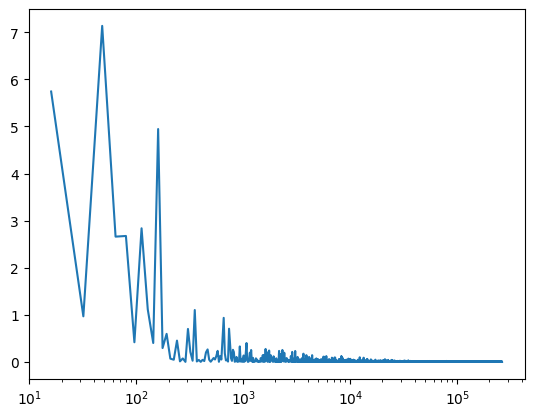

In [133]:
def measurement_accuracy(QuantumVSAs, verbose=False):
    # Create the VSA state corresponding to |phi> = alpha * |0> + beta * |1>
    # Randomly sample alpha and beta as complex numbers in the complex unit disc
    alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
    # Make sure alpha and beta are normalized
    alpha, beta = (alpha / (alpha.conjugate() * alpha + beta.conjugate() * beta),
                   beta  / (alpha.conjugate() * alpha + beta.conjugate() * beta))
    if verbose:
        print("Alpha and Beta after Normalization:", alpha, beta)
    # The first index of QuantumVSAs.VSAs is the qubit number, the second index is the state value
    phi = alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1]

    # Once we create the state, we can try obtaining the probability of measuring |0> and |1>
    dp0 = (phi * QuantumVSAs.VSAs[0][0]).sum().numpy()
    p0  = dp0.conjugate() * dp0
    dp1 = (phi * QuantumVSAs.VSAs[0][1]).sum().numpy()
    p1  = dp1.conjugate() * dp1

    if verbose:
        print("Probability of measuring 0 and 1 (VSA):", p0.real, p1.real)
        print("Probability of measuring 0 and 1 (actual):", (alpha*alpha.conjugate()).real, (beta*beta.conjugate()).real)
        print("Probability of measuring 0 and 1 (error):", p0.real - (alpha*alpha.conjugate()).real, p1.real - (beta*beta.conjugate()).real)
        print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - (alpha*alpha.conjugate()).real) / (alpha*alpha.conjugate()).real * 100, 
                                                                   abs(p1.real - (beta*beta.conjugate()).real) / (beta*beta.conjugate()).real * 100)
    
    return (abs(p0.real - (alpha*alpha.conjugate()).real) / (alpha*alpha.conjugate()).real * 100 + abs(p1.real - (beta*beta.conjugate()).real) / (beta*beta.conjugate()).real * 100) / 2

n_trials = 10000
average_errors = []
VSA_dims       = np.arange(16, 262144, 16) # [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
for trial_VSA_dim in VSA_dims:
    QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=trial_VSA_dim, n_qubits=1, n_states=2)
    errors = []
    for n in range(n_trials):
        errors += [measurement_accuracy(QuantumVSAs)]

#     print("Average Percentage error:", np.array(errors).mean())
#     plt.hist(errors, bins=100)
#     plt.title("VSA dim: " + str(trial_VSA_dim) + ", average error: " + str(np.array(errors).mean()))
#     plt.xlim((0, 100))
#     plt.show()
    
    average_errors += [np.array(errors).mean()]
    
plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Average Percentage Error")
plt.title("Average Measurement Error (%) vs. VSA Dimensionality")
plt.grid()
plt.show()

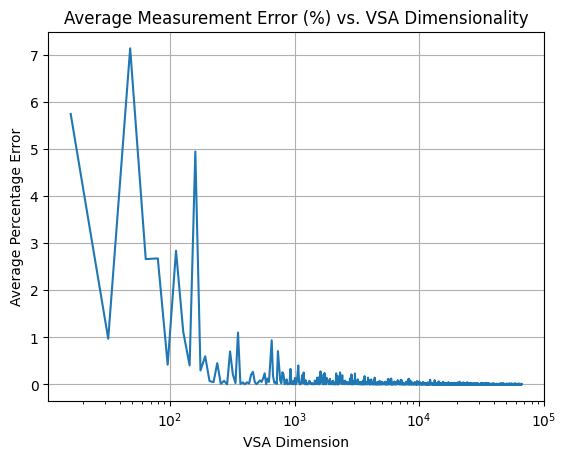

In [134]:
plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Average Percentage Error")
plt.title("Average Measurement Error (%) vs. VSA Dimensionality")
plt.grid()
plt.show()

## Gate Application

In [4]:
VSA_dim = 4096
n_qubits = 10 # Ten qubit system (We don't need to use all 10 qubits)
n_states = 2 # Two level system
verbose = True
QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=VSA_dim, n_qubits=n_qubits, n_states=n_states)

# Randomly sample alpha and beta as complex numbers in the complex unit disc
alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
alpha, beta  = 1/np.sqrt(2), 1/np.sqrt(2) #np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
print("Alpha and Beta after Normalization:", alpha, beta)
# Make sure alpha and beta are normalized
alpha, beta = (alpha / (alpha.conjugate() * alpha + beta.conjugate() * beta),
               beta  / (alpha.conjugate() * alpha + beta.conjugate() * beta))
#alpha = 1
#beta = 0

phi = alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1]

# In matrix form,
#  H = 1/sqrt(2) ((1,  1),
#                 (1, -1))
# We can measure the impact H has on the basis states |0> and |1> in order to create a VSA equivalent to H:
#  H|0> = 1/sqrt(2)(|0> + |1>), H|1> = 1/sqrt(2)(|0> - |1>)
H = 1/np.sqrt(2) * (bind(QuantumVSAs.inverse_VSAs[0][0], (QuantumVSAs.VSAs[0][0] + QuantumVSAs.VSAs[0][1])) +
                    bind(QuantumVSAs.inverse_VSAs[0][1], (QuantumVSAs.VSAs[0][0] - QuantumVSAs.VSAs[0][1])))

# When H is applied to |phi> = alpha * |0> + beta * |1>, the resultant state will be:
#  H(alpha * |0> + beta * |1>) = 1/sqrt(2)(alpha + beta)|0> + (alpha - beta)|1>
phi_prime = bind(phi, H)

# Once again, to measure the accuracy of our transformation, we find the probability of measuring |0> and |1> from phi_prime
#  and compare it to the actual probability of those outcomes

dp0 = (phi_prime * QuantumVSAs.VSAs[0][0]).sum().numpy()
p0  = dp0.conjugate() * dp0
dp1 = (phi_prime * QuantumVSAs.VSAs[0][1]).sum().numpy()
p1  = dp1.conjugate() * dp1

if verbose:
    print("Probability of measuring 0 and 1 (VSA):", p0.real, p1.real)
    print("Probability of measuring 0 and 1 (actual):", 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                        1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (error):", p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                       p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real) / 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real * 100, 
                                                               abs(p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real) / 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real * 100)


Alpha and Beta after Normalization: 0.7071067811865475 0.7071067811865475
Probability of measuring 0 and 1 (VSA): 0.25173536 0.25511873
Probability of measuring 0 and 1 (actual): 1.0000000000000002 0.0
Probability of measuring 0 and 1 (error): -0.7482646405696871 0.255118727684021
Probability of measuring 0 and 1 (percent error): 74.82646405696872 0.0


In [5]:
def H_gate_decoding(phi, QuantumVSAs, qubit=0):
    """
    Apply Hadamard gate to a specific qubit in the VSA representation.
    This works by extracting coefficients, transforming them, and reconstructing.
    """
    # For single qubit, extract the two coefficients
    coeff_0 = (phi * QuantumVSAs.VSAs[qubit][0]).sum()
    coeff_1 = (phi * QuantumVSAs.VSAs[qubit][1]).sum()
    
    # Apply Hadamard transformation
    new_coeff_0 = 1/np.sqrt(2) * (coeff_0 + coeff_1)
    new_coeff_1 = 1/np.sqrt(2) * (coeff_0 - coeff_1)
    
    # Reconstruct the state
    return new_coeff_0 * QuantumVSAs.VSAs[qubit][0] + new_coeff_1 * QuantumVSAs.VSAs[qubit][1]

def create_H_gate_rms(QuantumVSAs, qubit=0):
    """
    Construct a single linear operator M (dim x dim) in VSA space that
    implements the Hadamard gate on the span of |0> and |1>:

        M v0 = (v0 + v1)/sqrt(2)
        M v1 = (v0 - v1)/sqrt(2)

    where v0, v1 are the VSA encodings of |0> and |1> for the given qubit.

    This is solved in closed form as M = T @ pinv(B), which is the
    least-squares / minimum-norm solution to minimizing ||M B - T||_F^2.
    """

    # Basis vectors in VSA space for |0>, |1>
    v0 = QuantumVSAs.VSAs[qubit][0]    # shape: (D,)
    v1 = QuantumVSAs.VSAs[qubit][1]    # shape: (D,)

    device = v0.device
    dtype  = torch.complex64

    # Stack them as columns: B = [v0 v1]  (D x 2)
    B = torch.stack([v0, v1], dim=1)

    # Targets: |+> = (|0> + |1>)/sqrt(2), |-> = (|0> - |1>)/sqrt(2)
    t0 = (v0 + v1) / np.sqrt(2.0)
    t1 = (v0 - v1) / np.sqrt(2.0)

    # T = [t0 t1]  (D x 2)
    T = torch.stack([t0, t1], dim=1)

    # Pseudoinverse of B: shape (2 x D)
    B_pinv = torch.linalg.pinv(B)

    # M = T B^+  => (D x 2) @ (2 x D) = (D x D)
    M = T @ B_pinv

    return M.type(dtype).to(device)


def create_vsa_gate_matrix(U, vsa_dict):
    """
    Construct a (D x D) VSA-space linear operator M that implements a gate U
    on a system of k 'sites' (qudits), where each site has s possible states.

    Assumptions:
      - vsa_dict.VSAs[i][j] is a tensor giving the VSA encoding for site i
        in local state j. It may be shape (D,) or (1, D); we flatten when
        building the basis matrix.
      - All sites 0..k-1 have the same number of local states s.
      - U is a square matrix of shape (N, N), with N = s**k.
      - The gate U is already the full unitary on those k sites.
      - The first k entries of vsa_dict.VSAs correspond to the sites that U acts on.
      - Multi-site states are encoded by recursively binding the per-site VSAs:
            v_global = bind(v_site0, v_site1, ..., v_site{k-1})
    """

    if U.shape[0] != U.shape[1]:
        raise ValueError(f"U must be square, got shape {U.shape}")

    N = U.shape[0]

    # --- Infer s from vsa_dict.VSAs[0] (qubits, qutrits, etc.) ---
    try:
        s = len(vsa_dict.VSAs[0])
    except Exception as e:
        raise ValueError(
            "Could not infer number of local states 's' from vsa_dict.VSAs[0]. "
            "Expected something indexable with len()."
        ) from e

    # --- Infer k from N = s**k ---
    k = None
    prod = 1
    for exp in range(0, 64):  # assume we don't have more than 64 sites
        if prod == N:
            k = exp
            break
        if prod > N:
            break
        prod *= s

    if k is None:
        raise ValueError(
            f"Cannot interpret U of size {N} as acting on k sites with s={s} "
            f"states each; no integer k with s**k == N."
        )

    if len(vsa_dict.VSAs) < k:
        raise ValueError(
            f"vsa_dict.VSAs has only {len(vsa_dict.VSAs)} sites, but U implies k={k}."
        )

    # --- Infer D, device, dtype from an example VSA ---
    site0 = vsa_dict.VSAs[0]
    if isinstance(site0, dict):
        example_vec = site0[next(iter(site0.keys()))]
    else:
        example_vec = site0[0]

    # example_vec might be shape (D,) or (1, D) etc.; flatten to get D
    D = example_vec.numel()
    device = example_vec.device
    base_dtype = example_vec.dtype
    dtype  = torch.complex64  # we work in complex; will cast tensors

    U = U.to(device=device, dtype=dtype)

    # --- Build basis matrix B: columns are encoded multi-site basis states ---
    basis_cols_flat = []

    for idx in range(N):
        # Convert idx to base-s digits of length k
        digits = []
        x = idx
        for _ in range(k):
            digits.append(x % s)
            x //= s
        # digits[i] is local state of site i

        v = None
        for site in range(k):
            local_container = vsa_dict.VSAs[site]
            if isinstance(local_container, dict):
                v_site = local_container[digits[site]]
            else:
                v_site = local_container[digits[site]]
            v_site = v_site.to(device=device, dtype=base_dtype)

            if v is None:
                v = v_site
            else:
                v = bind(v, v_site)   # keep whatever internal shape bind expects

        # Flatten to 1D length D for inclusion in the basis matrix
        v_flat = v.reshape(D).to(dtype=dtype)
        basis_cols_flat.append(v_flat)

    # Now B has shape (D, N): VSA_dim × #basis
    B = torch.stack(basis_cols_flat, dim=1)   # (D, N)

    # --- Target matrix T = B @ U ---
    T = B @ U  # (D, N)

    # --- Pseudoinverse and final gate matrix ---
    B_pinv = torch.linalg.pinv(B)  # (N, D)
    M = T @ B_pinv                 # (D, D)

    return M.type(dtype).to(device)

    
VSA_dim = 2048
n_qubits = 1
n_states = 2
verbose = True
QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=VSA_dim, n_qubits=n_qubits, n_states=n_states)

alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
#alpha, beta  = 1/np.sqrt(2), 1/np.sqrt(2) #np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
# Make sure alpha and beta are normalized
alpha, beta = (alpha / (alpha.conjugate() * alpha + beta.conjugate() * beta),
               beta  / (alpha.conjugate() * alpha + beta.conjugate() * beta))
print("Alpha and Beta after Normalization:", alpha, beta)

phi = alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1]

# Apply Hadamard using the coefficient approach
#H = create_H_gate_rms(QuantumVSAs, qubit=0)
H = 1/np.sqrt(2) * torch.tensor([[1, 1], [1, -1]])
H = create_vsa_gate_matrix(U=H, vsa_dict=QuantumVSAs)
phi_prime = H @ phi
#phi_prime = apply_hadamard_gate(phi, QuantumVSAs, qubit=0)

# Measure probabilities
dp0 = (phi_prime * QuantumVSAs.VSAs[0][0]).sum().numpy()
p0 = (dp0.conjugate() * dp0).real
dp1 = (phi_prime * QuantumVSAs.VSAs[0][1]).sum().numpy()
p1 = (dp1.conjugate() * dp1).real

if verbose:
    print("Probability of measuring 0 and 1 (VSA):", p0.real, p1.real)
    print("Probability of measuring 0 and 1 (actual):", 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                        1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (error):", p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                       p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real) / 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real * 100, 
                                                               abs(p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real) / 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real * 100)


Alpha and Beta after Normalization: (-0.33519460450375643+0.8631971710674633j) (-0.3208154932369659-0.38688404321345143j)
Probability of measuring 0 and 1 (VSA): 0.32861146 0.7814441
Probability of measuring 0 and 1 (actual): 0.32861172205193223 0.7814549005694346
Probability of measuring 0 and 1 (error): -2.587435978806951e-07 -1.0827846045891043e-05
Probability of measuring 0 and 1 (percent error): 8.502617926948792e-06 0.0008461473355172931


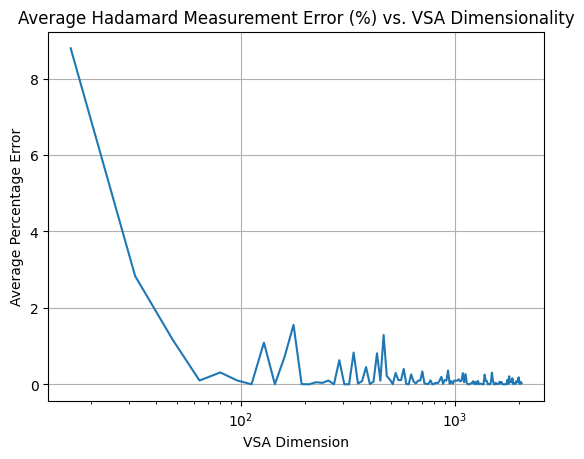

In [6]:
def H_gate_decoding(phi, QuantumVSAs, qubit=0):
    """
    Apply Hadamard gate to a specific qubit in the VSA representation.
    This works by extracting coefficients, transforming them, and reconstructing.
    """
    coeff_0 = (phi * QuantumVSAs.VSAs[qubit][0]).sum()
    coeff_1 = (phi * QuantumVSAs.VSAs[qubit][1]).sum()
    
    new_coeff_0 = (coeff_0 + coeff_1) / np.sqrt(2.0)
    new_coeff_1 = (coeff_0 - coeff_1) / np.sqrt(2.0)
    
    return new_coeff_0 * QuantumVSAs.VSAs[qubit][0] + new_coeff_1 * QuantumVSAs.VSAs[qubit][1]


# ------------------------------------------------------------
# Hadamard gate accuracy (like measurement_accuracy but with H)
# ------------------------------------------------------------
def hadamard_accuracy(QuantumVSAs, M_H, verbose=False):
    """
    Sample a random 1-qubit state |phi> = alpha|0> + beta|1>,
    apply the VSA-space Hadamard matrix M_H, and compare the
    resulting measurement probabilities to the exact quantum result.

    Returns:
        average percent error over p(0) and p(1).
    """

    # Sample random complex alpha, beta and normalize
    alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(
        1.j * np.random.uniform(0, 2 * np.pi, 2)
    )
    norm = np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta)
    alpha /= norm
    beta  /= norm

    if verbose:
        print("Alpha and Beta after normalization:", alpha, beta)

    v0 = QuantumVSAs.VSAs[0][0]
    v1 = QuantumVSAs.VSAs[0][1]

    # Encode |phi> in VSA space
    phi = alpha * v0 + beta * v1

    # Apply VSA-space Hadamard
    phi_prime = M_H @ phi

    # VSA-measured probabilities
    dp0 = (phi_prime * v0).sum().numpy()
    p0  = (dp0.conjugate() * dp0).real
    dp1 = (phi_prime * v1).sum().numpy()
    p1  = (dp1.conjugate() * dp1).real

    # Exact quantum probabilities after H:
    # |phi'> = H|phi> = (alpha+beta)/sqrt(2)|0> + (alpha-beta)/sqrt(2)|1>
    p0_true = 0.5 * ((alpha + beta) * (alpha + beta).conjugate()).real
    p1_true = 0.5 * ((alpha - beta) * (alpha - beta).conjugate()).real

    err0 = abs(p0 - p0_true) / p0_true * 100.0
    err1 = abs(p1 - p1_true) / p1_true * 100.0

    if verbose:
        print("VSA probs:", p0, p1)
        print("True probs:", p0_true, p1_true)
        print("Percent errors:", err0, err1)

    return (err0 + err1) / 2.0


# ------------------------------------------------------------
# Accuracy vs VSA dimension loop (analogous to measurement_accuracy loop)
# ------------------------------------------------------------
n_trials = 1000         # you can bump this up if you want tighter estimates
average_errors = []
VSA_dims       = np.arange(16, 2048 + 1, 16)  # tweak as you like

for trial_VSA_dim in VSA_dims:
    # One-qubit, 2-state system
    QuantumVSAs = SymbolicEngineQuantumVSA(
        VSA_dim=trial_VSA_dim, n_qubits=1, n_states=2
    )

    # Define 1-qubit Hadamard in computational basis
    H = (1.0 / np.sqrt(2.0)) * torch.tensor(
        [[1,  1],
         [1, -1]],
        dtype=torch.complex64,
        device=QuantumVSAs.VSAs[0][0].device
    )

    # Build VSA-space Hadamard matrix once per VSA_dim
    M_H = create_vsa_gate_matrix(U=H, vsa_dict=QuantumVSAs)

    errors = []
    for _ in range(n_trials):
        errors.append(hadamard_accuracy(QuantumVSAs, M_H, verbose=False))

    avg_err = np.mean(errors)
    average_errors.append(avg_err)
    #print(f"VSA_dim={trial_VSA_dim}, avg % error={avg_err:.4f}")

# Plot
plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Average Percentage Error")
plt.title("Average Hadamard Measurement Error (%) vs. VSA Dimensionality")
plt.grid(True)
plt.show()


## Quantum Teleportation

In [16]:
import numpy as np
import torch

# ---------- 1. General gate → VSA matrix (works with your VSAs + bind) ----------

def create_vsa_gate_matrix(U, vsa_dict):
    """
    Construct a (D x D) VSA-space linear operator M that implements a gate U
    on k sites with s local states each.

    Conventions:
      - Sites are indexed 0..k-1.
      - Basis index 'idx' is interpreted in *big-endian* base-s:
            idx = d0 * s^(k-1) + d1 * s^(k-2) + ... + d_{k-1}
        where di is the local state at site i.
      - vsa_dict.VSAs[site][state] gives a vector of length D.
      - Multi-site basis VSAs are constructed by recursive bind(...)
        and then flattened to shape (D,).
      - B has shape (D, N) with N = s**k. States are column vectors (D,).
    """

    if U.shape[0] != U.shape[1]:
        raise ValueError(f"U must be square, got shape {U.shape}")
    N = U.shape[0]

    # infer number of local states
    try:
        s = len(vsa_dict.VSAs[0])
    except Exception as e:
        raise ValueError("Could not infer s from vsa_dict.VSAs[0].") from e

    # infer k from N = s**k
    k = None
    prod = 1
    for exp in range(64):
        if prod == N:
            k = exp
            break
        if prod > N:
            break
        prod *= s
    if k is None:
        raise ValueError(f"Cannot interpret U of size {N} as s**k with s={s}.")

    if len(vsa_dict.VSAs) < k:
        raise ValueError(
            f"vsa_dict.VSAs has only {len(vsa_dict.VSAs)} sites, but U implies k={k}."
        )

    # get D, device, dtype from a sample VSA
    site0 = vsa_dict.VSAs[0]
    example_vec = site0[0] if not isinstance(site0, dict) else site0[next(iter(site0.keys()))]
    D = example_vec.numel()
    device = example_vec.device
    base_dtype = example_vec.dtype
    dtype = torch.complex64

    U = U.to(device=device, dtype=dtype)

    # build B: columns = flattened multi-site basis VSAs in big-endian order
    basis_cols_flat = []
    for idx in range(N):
        # big-endian base-s digits: digits[0] is site 0 (MSB-ish)
        digits = [0] * k
        x = idx
        for pos in range(k - 1, -1, -1):
            digits[pos] = x % s
            x //= s

        v = None
        for site in range(k):
            local_container = vsa_dict.VSAs[site]
            v_site = (
                local_container[digits[site]]
                if not isinstance(local_container, dict)
                else local_container[digits[site]]
            )
            v_site = v_site.to(device=device, dtype=base_dtype)
            if v is None:
                v = v_site
            else:
                v = bind(v, v_site)  # returns (1, D)

        v_flat = v.reshape(D).to(dtype=dtype)
        basis_cols_flat.append(v_flat)

    B = torch.stack(basis_cols_flat, dim=1)  # (D, N)

    # T = B U, then M = T B^+
    T = B @ U                    # (D, N)
    B_pinv = torch.linalg.pinv(B)   # (N, D)
    M = T @ B_pinv               # (D, D)

    return M.type(dtype).to(device)


# ---------- 2. 3-qubit basis in VSA space ----------

def build_3qubit_basis_vsas(QuantumVSAs):
    """
    Return:
        basis_vsas: list of 8 VSA vectors (D,) corresponding to
                    |000>, |001>, ..., |111> in big-endian order:
                    idx = a*4 + b*2 + c  (a=q0, b=q1, c=q2)
        s: number of local states (2 for qubits).
    """
    s = len(QuantumVSAs.VSAs[0])
    k = 3
    assert s == 2, "Assuming qubits here."

    site0 = QuantumVSAs.VSAs[0]
    example_vec = site0[0] if not isinstance(site0, dict) else site0[next(iter(site0.keys()))]
    D = example_vec.numel()
    device = example_vec.device
    dtype = example_vec.dtype

    basis_vsas = []
    N = s ** k

    for idx in range(N):
        # big-endian digits
        digits = [0] * k
        x = idx
        for pos in range(k - 1, -1, -1):
            digits[pos] = x % s
            x //= s

        v = None
        for site in range(k):
            local_container = QuantumVSAs.VSAs[site]
            v_site = (
                local_container[digits[site]]
                if not isinstance(local_container, dict)
                else local_container[digits[site]]
            )
            v_site = v_site.to(device=device, dtype=dtype)
            if v is None:
                v = v_site
            else:
                v = bind(v, v_site)   # (1, D)

        basis_vsas.append(v.reshape(D))

    return basis_vsas, s


# ---------- 3. Build teleportation gates in VSA space ----------

def build_teleportation_gates(QuantumVSAs):
    """
    Build 3-qubit VSA-space gate matrices for:
      - CNOT(0→1)
      - H on qubit 0
      - X on qubit 2
      - Z on qubit 2

    All returned matrices have shape (D, D) and act on column vectors.
    """
    device = QuantumVSAs.VSAs[0][0].device
    dtype  = torch.complex64

    I2 = torch.eye(2, dtype=dtype, device=device)

    H = (1.0 / math.sqrt(2.0)) * torch.tensor(
        [[1,  1],
         [1, -1]],
        dtype=dtype,
        device=device,
    )

    X = torch.tensor([[0, 1],
                      [1, 0]], dtype=dtype, device=device)

    Z = torch.tensor([[1,  0],
                      [0, -1]], dtype=dtype, device=device)

    # 2-qubit CNOT with control=q0 (MSB), target=q1 (second bit)
    # basis ordering: |00>, |01>, |10>, |11> with index = a*2 + b
    C = torch.zeros((4, 4), dtype=dtype, device=device)
    for a in (0, 1):   # control
        for b in (0, 1):  # target
            in_idx = a * 2 + b
            out_b  = b ^ a      # flip target iff control==1
            out_idx = a * 2 + out_b
            C[out_idx, in_idx] = 1.0

    # 3-qubit unitaries in big-endian ordering |q0 q1 q2>
    U_CNOT01 = torch.kron(C, I2)                        # CNOT(0→1) on (q0,q1)
    U_H0     = torch.kron(H, torch.kron(I2, I2))        # H ⊗ I ⊗ I
    U_X2     = torch.kron(torch.kron(I2, I2), X)        # I ⊗ I ⊗ X
    U_Z2     = torch.kron(torch.kron(I2, I2), Z)        # I ⊗ I ⊗ Z

    M_CNOT01 = create_vsa_gate_matrix(U_CNOT01, QuantumVSAs)
    M_H0     = create_vsa_gate_matrix(U_H0,     QuantumVSAs)
    M_X2     = create_vsa_gate_matrix(U_X2,     QuantumVSAs)
    M_Z2     = create_vsa_gate_matrix(U_Z2,     QuantumVSAs)

    return M_CNOT01, M_H0, M_X2, M_Z2


# ---------- 4. One teleportation run (no shape errors) ----------

def teleportation_trial(QuantumVSAs, verbose=True):
    """
    Run a single teleportation circuit using the VSA gate matrices.
    This version is mostly to verify that the circuit runs end-to-end
    without any shape errors and produces a sensible state.
    """

    # random alpha, beta
    alpha, beta = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(
        1.j * np.random.uniform(0, 2 * np.pi, 2)
    )
    #alpha, beta = 1/np.sqrt(2), 1/np.sqrt(2)
    norm = np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta)
    alpha /= norm
    beta  /= norm
    if verbose:
        print("Alpha and Beta after Normalization:", alpha, beta)

    basis_vsas, s = build_3qubit_basis_vsas(QuantumVSAs)

    # index helper: big-endian |abc> -> a*4 + b*2 + c
    def idx_abc(a, b, c):
        return a * 4 + b * 2 + c

    # initial state |ψ>_0 ⊗ (|00> + |11>)/√2
    phi0 = (
        alpha / np.sqrt(2.0) * basis_vsas[idx_abc(0, 0, 0)]
        + alpha / np.sqrt(2.0) * basis_vsas[idx_abc(0, 1, 1)]
        + beta  / np.sqrt(2.0) * basis_vsas[idx_abc(1, 0, 0)]
        + beta  / np.sqrt(2.0) * basis_vsas[idx_abc(1, 1, 1)]
    )  # shape (D,)

    phi0 = phi0.type(torch.complex64)
    
    if verbose:
        print("phi0 shape:", phi0.shape)

    M_CNOT01, M_H0, M_X2, M_Z2 = build_teleportation_gates(QuantumVSAs)

    # apply CNOT(0→1) then H on qubit 0
    phi1 = M_CNOT01 @ phi0
    phi2 = M_H0 @ phi1

    if verbose:
        print("phi2 shape after H·CNOT:", phi2.shape)

    # (from here you can do measurement, corrections, etc.)
    return phi2

def teleportation_trial_abs_error(QuantumVSAs, alpha, beta, verbose=False):
    """
    Run teleportation for fixed |ψ> = α|0> + β|1> and compare Bob's
    final measurement probabilities to the true ones, for each branch (a,b).
    """

    # 1) normalize
    norm = math.sqrt((alpha.conjugate()*alpha + beta.conjugate()*beta).real)
    alpha /= norm
    beta  /= norm

    print("State:", alpha, beta)
    basis_vsas, s = build_3qubit_basis_vsas(QuantumVSAs)

    def idx_abc(a, b, c):
        # big-endian index for |a b c>
        return a * 4 + b * 2 + c

    # 2) prepare initial state: |ψ>_0 ⊗ (|00> + |11>)/√2
    phi0 = (
        alpha / math.sqrt(2) * basis_vsas[idx_abc(0, 0, 0)] +
        alpha / math.sqrt(2) * basis_vsas[idx_abc(0, 1, 1)] +
        beta  / math.sqrt(2) * basis_vsas[idx_abc(1, 0, 0)] +
        beta  / math.sqrt(2) * basis_vsas[idx_abc(1, 1, 1)]
    )  # (D,)

    # 3) apply CNOT(0→1) then H on qubit 0
    M_CNOT01, M_H0, M_X2, M_Z2 = build_teleportation_gates(QuantumVSAs)
    phi1 = M_CNOT01 @ phi0
    phi2 = M_H0 @ phi1  # (D,)

    # 4) decompose into computational basis
    coeffs = []
    for idx in range(8):
        c = (phi2 * basis_vsas[idx]).sum().cpu().numpy()
        coeffs.append(c)

    results = {}
    for a in (0, 1):
        for b in (0, 1):
            i0 = idx_abc(a, b, 0)
            i1 = idx_abc(a, b, 1)

            c0 = coeffs[i0]
            c1 = coeffs[i1]

            prob = (c0.conjugate()*c0 + c1.conjugate()*c1).real
            prob = float(prob)

            if prob < 1e-10:
                results[(a, b)] = {"prob": prob, "abs_err": None}
                continue

            # post-measurement branch state
            norm_branch = math.sqrt((c0.conjugate()*c0 + c1.conjugate()*c1).real)
            phi_post = (c0/norm_branch)*basis_vsas[i0] + (c1/norm_branch)*basis_vsas[i1]

            # 5) apply corrections X^b Z^a on Bob's qubit (q2)
            phi_corr = phi_post.type(torch.complex64)
            if b == 1:
                phi_corr = M_X2 @ phi_corr
            if a == 1:
                phi_corr = M_Z2 @ phi_corr

            # 6) decode Bob's local state amplitudes in this branch
            d0 = (phi_corr * basis_vsas[i0]).sum().cpu().numpy()
            d1 = (phi_corr * basis_vsas[i1]).sum().cpu().numpy()

            norm_bob = math.sqrt((d0.conjugate()*d0 + d1.conjugate()*d1).real)
            d0 /= norm_bob
            d1 /= norm_bob

            p0_vsa = (d0.conjugate()*d0).real
            p1_vsa = (d1.conjugate()*d1).real

            p0_true = (alpha.conjugate()*alpha).real
            p1_true = (beta.conjugate()*beta).real

            abs_err = float(abs(p0_vsa - p0_true) + abs(p1_vsa - p1_true))

            results[(a, b)] = {
                "prob": prob,
                "p_vsa": (float(p0_vsa), float(p1_vsa)),
                "p_true": (float(p0_true), float(p1_true)),
                "abs_err": abs_err,
            }

    return results

def run_simple_teleportation_tests():
    VSA_dim = 512
    QuantumVSAs = SymbolicEngineQuantumVSA(
        VSA_dim=VSA_dim, n_qubits=3, n_states=2
    )

    tests = [
        ("|0⟩", 1+0j, 0+0j),
        ("|1⟩", 0+0j, 1+0j),
        ("|+⟩", 1/math.sqrt(2)+0j, 1/math.sqrt(2)+0j),
        ("|phi⟩", 23+0j, 42+0j),
    ]

    for name, a, b in tests:
        print(f"\n=== Teleportation test for {name} ===")
        res = teleportation_trial_abs_error(QuantumVSAs, a, b, verbose=False)
        for (ab), info in res.items():
            print(f"Outcome (a,b)={ab}:")
            print(f"  branch prob ≈ {info['prob']:.4f}")
            if info["abs_err"] is None:
                print("  (negligible branch)")
                continue
            p0_vsa, p1_vsa = info["p_vsa"]
            p0_true, p1_true = info["p_true"]
            print(f"  Bob p_vsa  ≈ ({p0_vsa:.4f}, {p1_vsa:.4f})")
            print(f"  Bob p_true ≈ ({p0_true:.4f}, {p1_true:.4f})")
            print(f"  abs_err    ≈ {info['abs_err']:.4e}")


run_simple_teleportation_tests()

# VSA_dim = 2048
# n_qubits = 3
# n_states = 2

# QuantumVSAs = SymbolicEngineQuantumVSA(
#     VSA_dim=VSA_dim, n_qubits=n_qubits, n_states=n_states
# )

# phi2 = teleportation_trial(QuantumVSAs, verbose=True)



=== Teleportation test for |0⟩ ===
State: (1+0j) 0j
Outcome (a,b)=(0, 0):
  branch prob ≈ 0.2247
  Bob p_vsa  ≈ (0.9984, 0.0016)
  Bob p_true ≈ (1.0000, 0.0000)
  abs_err    ≈ 3.1105e-03
Outcome (a,b)=(0, 1):
  branch prob ≈ 0.1985
  Bob p_vsa  ≈ (0.9807, 0.0193)
  Bob p_true ≈ (1.0000, 0.0000)
  abs_err    ≈ 3.8693e-02
Outcome (a,b)=(1, 0):
  branch prob ≈ 0.2064
  Bob p_vsa  ≈ (0.9842, 0.0158)
  Bob p_true ≈ (1.0000, 0.0000)
  abs_err    ≈ 3.1557e-02
Outcome (a,b)=(1, 1):
  branch prob ≈ 0.2164
  Bob p_vsa  ≈ (0.9975, 0.0025)
  Bob p_true ≈ (1.0000, 0.0000)
  abs_err    ≈ 4.9308e-03

=== Teleportation test for |1⟩ ===
State: 0j (1+0j)
Outcome (a,b)=(0, 0):
  branch prob ≈ 0.2090
  Bob p_vsa  ≈ (0.0021, 0.9979)
  Bob p_true ≈ (0.0000, 1.0000)
  abs_err    ≈ 4.1129e-03
Outcome (a,b)=(0, 1):
  branch prob ≈ 0.2172
  Bob p_vsa  ≈ (0.0008, 0.9992)
  Bob p_true ≈ (0.0000, 1.0000)
  abs_err    ≈ 1.5869e-03
Outcome (a,b)=(1, 0):
  branch prob ≈ 0.2304
  Bob p_vsa  ≈ (0.0014, 0.9986)
  Bob p

/tmp/ipykernel_1130/898353866.py:307: ComplexWarning: Casting complex values to real discards the imaginary part
  phi_post = (c0/norm_branch)*basis_vsas[i0] + (c1/norm_branch)*basis_vsas[i1]


In [8]:
# VSA_dim = 2048
# n_qubits = 3
# n_states = 2
# verbose = True
# QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=VSA_dim, n_qubits=n_qubits, n_states=n_states)

# alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
# #alpha, beta  = 1/np.sqrt(2), 1/np.sqrt(2) #np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
# # Make sure alpha and beta are normalized
# alpha, beta = (alpha / (alpha.conjugate() * alpha + beta.conjugate() * beta),
#                beta  / (alpha.conjugate() * alpha + beta.conjugate() * beta))
# print("Alpha and Beta after Normalization:", alpha, beta)

# phi = bind(alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1], 1/np.sqrt(2) * bind(bind(QuantumVSAs.VSAs[1][0], QuantumVSAs.VSAs[2][0]), 
#                                                                                                bind(QuantumVSAs.VSAs[1][1], QuantumVSAs.VSAs[2][1])))
# phi = phi.flatten()
# phi = phi.type(torch.complex64)

# CNOT_12 = torch.tensor([[1, 0, 0, 0],
#                         [0, 1, 0, 0],
#                         [0, 0, 0, 1],
#                         [0, 0, 1, 0]])
# CNOT_12 = torch.kron(CNOT_01, torch.eye(2))
# CNOT_12 = create_vsa_gate_matrix(U=CNOT_12, vsa_dict=QuantumVSAs)
# phi = CNOT_12 @ phi
# H = 1/np.sqrt(2) * torch.tensor([[1, 1], [1, -1]])
# H = create_vsa_gate_matrix(U=H, vsa_dict=QuantumVSAs)
# phi_prime = H @ phi
# #phi_prime = apply_hadamard_gate(phi, QuantumVSAs, qubit=0)

# # Measure probabilities
# dp0 = (phi_prime * QuantumVSAs.VSAs[0][0]).sum().numpy()
# p0 = (dp0.conjugate() * dp0).real
# dp1 = (phi_prime * QuantumVSAs.VSAs[0][1]).sum().numpy()
# p1 = (dp1.conjugate() * dp1).real

# if verbose:
#     print("Probability of measuring 0 and 1 (VSA):", p0.real, p1.real)
#     print("Probability of measuring 0 and 1 (actual):", 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
#                                                         1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
#     print("Probability of measuring 0 and 1 (error):", p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
#                                                        p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
#     print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real) / 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real * 100, 
#                                                                abs(p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real) / 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real * 100)


In [13]:
# ---------- 2-qubit basis in VSA space ----------

def build_2qubit_basis_vsas(QuantumVSAs):
    """
    Return:
        basis_vsas: list of 4 VSA vectors (D,) corresponding to
                    |00>, |01>, |10>, |11> in big-endian order:
                        idx = a*2 + b  (a = q0, b = q1)
        s: number of local states (2 for qubits).
    """
    s = len(QuantumVSAs.VSAs[0])
    k = 2
    assert s == 2, "Assuming qubits here."

    site0 = QuantumVSAs.VSAs[0]
    example_vec = site0[0] if not isinstance(site0, dict) else site0[next(iter(site0.keys()))]
    D = example_vec.numel()
    device = example_vec.device
    dtype = example_vec.dtype

    basis_vsas = []
    N = s ** k  # 4

    for idx in range(N):
        # big-endian digits: |a b> with idx = a*2 + b
        digits = [0] * k
        x = idx
        for pos in range(k - 1, -1, -1):
            digits[pos] = x % s
            x //= s

        v = None
        for site in range(k):
            local_container = QuantumVSAs.VSAs[site]
            v_site = (
                local_container[digits[site]]
                if not isinstance(local_container, dict)
                else local_container[digits[site]]
            )
            v_site = v_site.to(device=device, dtype=dtype)

            if v is None:
                v = v_site
            else:
                v = bind(v, v_site)   # (1, D)

        basis_vsas.append(v.reshape(D).type(torch.complex64))

    return basis_vsas, s

def encode_2qubit_state(amps, basis_vsas):
    """
    Encode a 2-qubit state with amplitudes amps = [a,b,c,d]
    in the VSA basis vectors basis_vsas[0..3] corresponding to
    |00>, |01>, |10>, |11>.

    Returns:
        phi: (D,) complex64 tensor
    """
    a, b, c, d = amps
    phi = (
        a * basis_vsas[0] +
        b * basis_vsas[1] +
        c * basis_vsas[2] +
        d * basis_vsas[3]
    )
    return phi.type(torch.complex64)

def partial_measure_first_qubit(phi, QuantumVSAs, basis_vsas=None):
    """
    Perform a partial measurement on the *first* qubit (q0) of a 2-qubit state
    encoded in VSA space, using the same decode+group strategy as in the
    teleportation code.

    Args:
        phi:         (D,) complex64 VSA vector (2-qubit state)
        QuantumVSAs: SymbolicEngineQuantumVSA with n_qubits >= 2
        basis_vsas:  optional list of 4 basis VSAs (D,) for |00>,|01>,|10>,|11>

    Returns:
        P0, P1:    floats, probabilities for q0 = 0 and q0 = 1
        phi0, phi1: (D,) complex64 tensors,
                    collapsed states for each outcome (normalized branches)
    """
    if basis_vsas is None:
        basis_vsas, _ = build_2qubit_basis_vsas(QuantumVSAs)

    device = phi.device
    dtype = phi.dtype

    # 1) Decode approximate amplitudes in the computational basis
    coeffs = []
    for idx in range(4):
        # Same style as your measurement code: <V_idx | phi> approximated by dot product
        c = (phi * basis_vsas[idx]).sum()
        coeffs.append(c)

    c00, c01, c10, c11 = coeffs  # |00>, |01>, |10>, |11>

    # 2) Born probabilities for q0
    P0 = (c00.conj()*c00 + c01.conj()*c01).real
    P1 = (c10.conj()*c10 + c11.conj()*c11).real

    P0 = float(P0)
    P1 = float(P1)

    # 3) Unnormalized branch states:
    #    outcome q0 = 0 -> keep |00>, |01>
    phi0_unnorm = c00 * basis_vsas[0] + c01 * basis_vsas[1]
    #    outcome q0 = 1 -> keep |10>, |11>
    phi1_unnorm = c10 * basis_vsas[2] + c11 * basis_vsas[3]

    # 4) Normalize each branch (if its prob is non-zero)
    if P0 > 1e-12:
        norm0 = torch.sqrt(torch.tensor(P0, dtype=dtype, device=device))
        phi0 = phi0_unnorm / norm0
    else:
        phi0 = phi0_unnorm

    if P1 > 1e-12:
        norm1 = torch.sqrt(torch.tensor(P1, dtype=dtype, device=device))
        phi1 = phi1_unnorm / norm1
    else:
        phi1 = phi1_unnorm

    return P0, P1, phi0, phi1

def apply_partial_measurement_first_qubit(phi, QuantumVSAs, basis_vsas=None, outcome=None):
    """
    Apply a partial measurement on q0 to the existing VSA state phi.

    If outcome is None, randomly sample according to Born probabilities.
    If outcome is 0 or 1, force that branch (useful for debugging).

    Returns:
        outcome: 0 or 1
        (P0, P1): probabilities for q0=0,1
        phi_new: collapsed (D,) complex64 VSA state after measurement
    """
    P0, P1, phi0, phi1 = partial_measure_first_qubit(phi, QuantumVSAs, basis_vsas)

    if outcome is None:
        total = P0 + P1
        if total <= 0:
            # Degenerate case
            return 0, (P0, P1), phi

        P0_norm = P0 / total
        r = np.random.rand()
        if r < P0_norm:
            outcome = 0
            phi_new = phi0
        else:
            outcome = 1
            phi_new = phi1
    else:
        if outcome == 0:
            phi_new = phi0
        elif outcome == 1:
            phi_new = phi1
        else:
            raise ValueError("Outcome must be None, 0, or 1.")

    return outcome, (P0, P1), phi_new

def run_simple_partial_measurement_tests():
    # 1) Instantiate your VSA engine
    VSA_dim = 512
    QuantumVSAs = SymbolicEngineQuantumVSA(
        VSA_dim=VSA_dim, n_qubits=2, n_states=2
    )

    basis_vsas, _ = build_2qubit_basis_vsas(QuantumVSAs)

    # Helper to pretty-print one test
    def run_test(name, amps):
        """
        amps: numpy array [a,b,c,d] defining |phi> = a|00> + b|01> + c|10> + d|11>
        """
        print(f"\n=== Test: {name} ===")
        # normalize amps
        amps = np.array(amps, dtype=np.complex128)
        amps = amps / np.linalg.norm(amps)
        a, b, c, d = amps

        # Encode into VSA
        phi = encode_2qubit_state(amps, basis_vsas)

        # True probabilities
        P0_true = (abs(a)**2 + abs(b)**2).real
        P1_true = (abs(c)**2 + abs(d)**2).real

        # VSA partial measurement
        P0_vsa, P1_vsa, phi0, phi1 = partial_measure_first_qubit(phi, QuantumVSAs, basis_vsas)

        print(f"True amplitudes: a,b,c,d = {amps}")
        print(f"P(q0=0) true ≈ {P0_true:.4f}, VSA ≈ {P0_vsa:.4f}")
        print(f"P(q0=1) true ≈ {P1_true:.4f}, VSA ≈ {P1_vsa:.4f}")
        print(f"P0+P1 (VSA)    = {P0_vsa + P1_vsa:.4f}")

        # Optionally, show one collapsed branch explicitly
        outcome, (P0, P1), phi_new = apply_partial_measurement_first_qubit(
            phi, QuantumVSAs, basis_vsas, outcome=0
        )
        print(f"\nCollapsed state for forced outcome q0={outcome}:")
        print(f"  P0 (used for normalization) ≈ {P0:.4f}")
        # We won't print the whole high-D vector, but you can inspect norms:
        print(f"  ||phi_new|| ≈ {torch.linalg.norm(phi_new).item():.4f}")

    # 2) A few tests:

    # (a) Simple + state on q0, |0> on q1: (|0>+|1>)/√2 ⊗ |0>
    #     => |phi> = (1/√2)|00> + 0|01> + (1/√2)|10> + 0|11>
    run_test("|+> ⊗ |0>", [1/np.sqrt(2), 0, 1/np.sqrt(2), 0])

    # (b) Known |00> state
    run_test("|00>", [1, 0, 0, 0])

    # (c) Known |11> state
    run_test("|11>", [0, 0, 0, 1])

    # (d) Random state
    amps_rand = np.random.randn(4) + 1j*np.random.randn(4)
    run_test("Random |phi>", amps_rand)


# Call the test driver
run_simple_partial_measurement_tests()



=== Test: |+> ⊗ |0> ===
True amplitudes: a,b,c,d = [0.70710678+0.j 0.        +0.j 0.70710678+0.j 0.        +0.j]
P(q0=0) true ≈ 0.5000, VSA ≈ 0.4983
P(q0=1) true ≈ 0.5000, VSA ≈ 0.4960
P0+P1 (VSA)    = 0.9943

Collapsed state for forced outcome q0=0:
  P0 (used for normalization) ≈ 0.4983
  ||phi_new|| ≈ 0.9991

=== Test: |00> ===
True amplitudes: a,b,c,d = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
P(q0=0) true ≈ 1.0000, VSA ≈ 0.9963
P(q0=1) true ≈ 0.0000, VSA ≈ 0.0000
P0+P1 (VSA)    = 0.9963

Collapsed state for forced outcome q0=0:
  P0 (used for normalization) ≈ 0.9963
  ||phi_new|| ≈ 0.9991

=== Test: |11> ===
True amplitudes: a,b,c,d = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
P(q0=0) true ≈ 0.0000, VSA ≈ 0.0001
P(q0=1) true ≈ 1.0000, VSA ≈ 0.9721
P0+P1 (VSA)    = 0.9721

Collapsed state for forced outcome q0=0:
  P0 (used for normalization) ≈ 0.0001
  ||phi_new|| ≈ 0.9976

=== Test: Random |phi> ===
True amplitudes: a,b,c,d = [ 0.6656165 -0.19811759j  0.07901775-0.21139695j -0.01510541-0.53887703j
  0.

In [12]:
test_partial_measurement_once(VSA_dim=512, verbose=True)

True amplitudes: a,b,c,d = [-0.01129678-0.47260238j -0.2812805 +0.48326042j -0.20992424-0.25912693j
 -0.35836207+0.47352054j]
P(q0=0) true ≈ 0.5361, VSA ≈ 0.5548
P(q0=1) true ≈ 0.4639, VSA ≈ 0.4779
P0+P1 (VSA) = 1.0327


((np.float64(0.5361399774203177), np.float64(0.46386002257968206)),
 (0.554790735244751, 0.4778802990913391))